In [5]:
import sys
sys.path.append('..')

import numpy as np
from environments.monty_hall_1 import MontyHall1Env
from algorithms.dynamic_programming import policy_iteration
from eval import evaluate_policy


In [6]:
pi, V = policy_iteration(
    MontyHall1Env.S, MontyHall1Env.A, MontyHall1Env.R,
    MontyHall1Env.p, MontyHall1Env.T,
    gamma=0.999, theta=0.0001
)

print("V =", V.round(4))
for s in [1, 2, 3]:
    action = np.argmax(pi[s])
    print(f"Etat {s} -> action {action} ({'GARDER' if action == 0 else 'CHANGER'})")

env = MontyHall1Env()
results = evaluate_policy(env, pi, num_episodes=5000)
print("Evaluation sur 5000 parties :", results)

V = [0.666  0.6667 0.6667 0.6667 0.    ]
Etat 1 -> action 1 (CHANGER)
Etat 2 -> action 1 (CHANGER)
Etat 3 -> action 1 (CHANGER)
Evaluation sur 5000 parties : {'mean_score': 0.6664, 'std_score': 0.4715, 'win_rate': 0.6664}


In [8]:
for gamma in [0.9, 0.99, 0.999]:
    pi, V = policy_iteration(
        MontyHall1Env.S, MontyHall1Env.A, MontyHall1Env.R,
        MontyHall1Env.p, MontyHall1Env.T,
        gamma=gamma, theta=0.0001
    )
    results = evaluate_policy(env, pi, num_episodes=5000)
    print(f"gamma={gamma} | V={V.round(3)} | {results}")

gamma=0.9 | V=[0.6   0.667 0.667 0.667 0.   ] | {'mean_score': 0.676, 'std_score': 0.468, 'win_rate': 0.676}
gamma=0.99 | V=[0.66  0.667 0.667 0.667 0.   ] | {'mean_score': 0.6762, 'std_score': 0.4679, 'win_rate': 0.6762}
gamma=0.999 | V=[0.666 0.667 0.667 0.667 0.   ] | {'mean_score': 0.659, 'std_score': 0.474, 'win_rate': 0.659}


1.2 Value iteration 


In [9]:
from algorithms.dynamic_programming import value_iteration

pi_vi, V_vi = value_iteration(
    MontyHall1Env.S, MontyHall1Env.A, MontyHall1Env.R,
    MontyHall1Env.p, MontyHall1Env.T,
    gamma=0.999, theta=0.0001
)

print("V (Value Iteration) =", V_vi.round(4))
for s in [1, 2, 3]:
    action = np.argmax(pi_vi[s])
    print(f"Etat {s} -> action {action} ({'GARDER' if action == 0 else 'CHANGER'})")

results_vi = evaluate_policy(env, pi_vi, num_episodes=5000)
print("Evaluation sur 5000 parties :", results_vi)

V (Value Iteration) = [0.666  0.6667 0.6667 0.6667 0.    ]
Etat 1 -> action 1 (CHANGER)
Etat 2 -> action 1 (CHANGER)
Etat 3 -> action 1 (CHANGER)
Evaluation sur 5000 parties : {'mean_score': 0.6708, 'std_score': 0.4699, 'win_rate': 0.6708}


2. MonteCarlo
2.1. montecarlo ES

In [10]:
from algorithms.monte_carlo import monte_carlo_es, on_policy_first_visit_mc_control, off_policy_mc_control
np.random.seed(0)
pi_mc_es, Q_mc_es = monte_carlo_es(env, gamma=0.999, num_episodes=20000)

print("Actions choisies aux états 1, 2, 3 (0=GARDER, 1=CHANGER) :")
for s in [1, 2, 3]:
    print(f"  Etat {s} -> {int(np.argmax(pi_mc_es[s]))}")

results_mc_es = evaluate_policy(env, pi_mc_es, num_episodes=5000)
print("Evaluation sur 5000 parties :", results_mc_es)

Actions choisies aux états 1, 2, 3 (0=GARDER, 1=CHANGER) :
  Etat 1 -> 0
  Etat 2 -> 0
  Etat 3 -> 0
Evaluation sur 5000 parties : {'mean_score': 0.3254, 'std_score': 0.4685, 'win_rate': 0.3254}


In [11]:
np.random.seed(0)
pi_on_mc, Q_on_mc = on_policy_first_visit_mc_control(env, gamma=0.999, epsilon=0.1, num_episodes=20000)

print("Actions choisies aux états 1, 2, 3 (0=GARDER, 1=CHANGER) :")
for s in [1, 2, 3]:
    print(f"  Etat {s} -> {int(np.argmax(pi_on_mc[s]))}")

results_on_mc = evaluate_policy(env, pi_on_mc, num_episodes=5000)
print("Evaluation sur 5000 parties :", results_on_mc)

Actions choisies aux états 1, 2, 3 (0=GARDER, 1=CHANGER) :
  Etat 1 -> 1
  Etat 2 -> 1
  Etat 3 -> 1
Evaluation sur 5000 parties : {'mean_score': 0.66, 'std_score': 0.4737, 'win_rate': 0.66}


In [12]:
np.random.seed(0)
pi_off_mc, Q_off_mc = off_policy_mc_control(env, gamma=0.999, num_episodes=20000)

print("Actions choisies aux états 1, 2, 3 (0=GARDER, 1=CHANGER) :")
for s in [1, 2, 3]:
    print(f"  Etat {s} -> {int(np.argmax(pi_off_mc[s]))}")

results_off_mc = evaluate_policy(env, pi_off_mc, num_episodes=5000)
print("Evaluation sur 5000 parties :", results_off_mc)

Actions choisies aux états 1, 2, 3 (0=GARDER, 1=CHANGER) :
  Etat 1 -> 1
  Etat 2 -> 1
  Etat 3 -> 1
Evaluation sur 5000 parties : {'mean_score': 0.6826, 'std_score': 0.4655, 'win_rate': 0.6826}


In [13]:
print(f"{'Algo':20s} | {'Action état 1':15s} | {'Win rate':10s}")
print(f"{'Monte Carlo ES':20s} | {'CHANGER' if np.argmax(pi_mc_es[1])==1 else 'GARDER':15s} | {results_mc_es['win_rate']}")
print(f"{'On-policy MC':20s} | {'CHANGER' if np.argmax(pi_on_mc[1])==1 else 'GARDER':15s} | {results_on_mc['win_rate']}")
print(f"{'Off-policy MC':20s} | {'CHANGER' if np.argmax(pi_off_mc[1])==1 else 'GARDER':15s} | {results_off_mc['win_rate']}")

Algo                 | Action état 1   | Win rate  
Monte Carlo ES       | GARDER          | 0.3254
On-policy MC         | CHANGER         | 0.66
Off-policy MC        | CHANGER         | 0.6826


3.Temporal difference learning

In [14]:
from algorithms.temporal_difference_learning import sarsa, q_learning
np.random.seed(0)
pi_sarsa, Q_sarsa = sarsa(env, gamma=0.999, alpha=0.1, epsilon=0.1, num_episodes=20000)

print("Actions choisies aux états 1, 2, 3 (0=GARDER, 1=CHANGER) :")
for s in [1, 2, 3]:
    print(f"  Etat {s} -> {int(np.argmax(pi_sarsa[s]))}")

results_sarsa = evaluate_policy(env, pi_sarsa, num_episodes=5000)
print("Evaluation sur 5000 parties :", results_sarsa)

Actions choisies aux états 1, 2, 3 (0=GARDER, 1=CHANGER) :
  Etat 1 -> 1
  Etat 2 -> 1
  Etat 3 -> 1
Evaluation sur 5000 parties : {'mean_score': 0.6612, 'std_score': 0.4733, 'win_rate': 0.6612}


In [15]:
np.random.seed(0)
pi_qlearning, Q_qlearning = q_learning(env, gamma=0.999, alpha=0.1, epsilon=0.1, num_episodes=20000)

print("Actions choisies aux états 1, 2, 3 (0=GARDER, 1=CHANGER) :")
for s in [1, 2, 3]:
    print(f"  Etat {s} -> {int(np.argmax(pi_qlearning[s]))}")

results_qlearning = evaluate_policy(env, pi_qlearning, num_episodes=5000)
print("Evaluation sur 5000 parties :", results_qlearning)

Actions choisies aux états 1, 2, 3 (0=GARDER, 1=CHANGER) :
  Etat 1 -> 1
  Etat 2 -> 1
  Etat 3 -> 1
Evaluation sur 5000 parties : {'mean_score': 0.6658, 'std_score': 0.4717, 'win_rate': 0.6658}


In [ ]:
print(f"{'Algo':20s} | {'Action état 1':15s} | {'Win rate':10s}")
print(f"{'Policy Iteration':20s} | {'CHANGER':15s} | {results['win_rate']}")   
print(f"{'Value Iteration':20s} | {'CHANGER':15s} | {results_vi['win_rate']}")
print(f"{'Monte Carlo ES':20s} | {'GARDER':15s} | {results_mc_es['win_rate']}")
print(f"{'On-policy MC':20s} | {'CHANGER':15s} | {results_on_mc['win_rate']}")
print(f"{'Off-policy MC':20s} | {'CHANGER':15s} | {results_off_mc['win_rate']}")
print(f"{'Sarsa':20s} | {'CHANGER' if np.argmax(pi_sarsa[1])==1 else 'GARDER':15s} | {results_sarsa['win_rate']}")
print(f"{'Q-Learning':20s} | {'CHANGER' if np.argmax(pi_qlearning[1])==1 else 'GARDER':15s} | {results_qlearning['win_rate']}")

Algo                 | Action état 1   | Win rate  
Policy Iteration     | CHANGER         | 0.659
Value Iteration      | CHANGER         | 0.6708
Monte Carlo ES       | GARDER          | 0.3254
On-policy MC         | CHANGER         | 0.66
Off-policy MC        | CHANGER         | 0.6826
Sarsa                | CHANGER         | 0.6612
Q-Learning           | CHANGER         | 0.6658


In [17]:
from algorithms.planning import dyna_q, dyna_q_plus
np.random.seed(0)
Q_dyna, pi_dyna = dyna_q(env, gamma=0.999, alpha=0.1, epsilon=0.1, max_steps=20000, N=10)

print("Actions choisies aux états 1, 2, 3 (0=GARDER, 1=CHANGER) :")
for s in [1, 2, 3]:
    print(f"  Etat {s} -> {int(np.argmax(pi_dyna[s]))}")

results_dyna = evaluate_policy(env, pi_dyna, num_episodes=5000)
print("Evaluation sur 5000 parties :", results_dyna)

Actions choisies aux états 1, 2, 3 (0=GARDER, 1=CHANGER) :
  Etat 1 -> 1
  Etat 2 -> 1
  Etat 3 -> 1
Evaluation sur 5000 parties : {'mean_score': 0.683, 'std_score': 0.4653, 'win_rate': 0.683}


In [18]:
np.random.seed(0)
Q_dyna_plus, pi_dyna_plus = dyna_q_plus(env, gamma=0.999, alpha=0.1, epsilon=0.1,
                                          max_steps=20000, N=10, kappa=0.001)

print("Actions choisies aux états 1, 2, 3 (0=GARDER, 1=CHANGER) :")
for s in [1, 2, 3]:
    print(f"  Etat {s} -> {int(np.argmax(pi_dyna_plus[s]))}")

results_dyna_plus = evaluate_policy(env, pi_dyna_plus, num_episodes=5000)
print("Evaluation sur 5000 parties :", results_dyna_plus)

Actions choisies aux états 1, 2, 3 (0=GARDER, 1=CHANGER) :
  Etat 1 -> 1
  Etat 2 -> 1
  Etat 3 -> 1
Evaluation sur 5000 parties : {'mean_score': 0.6784, 'std_score': 0.4671, 'win_rate': 0.6784}


In [19]:
print(f"{'Algo':20s} | {'Action état 1':15s} | {'Win rate':10s}")
print(f"{'Policy Iteration':20s} | {'CHANGER':15s} | {results['win_rate']}")
print(f"{'Value Iteration':20s} | {'CHANGER':15s} | {results_vi['win_rate']}")
print(f"{'Monte Carlo ES':20s} | {'GARDER':15s} | {results_mc_es['win_rate']}")
print(f"{'On-policy MC':20s} | {'CHANGER':15s} | {results_on_mc['win_rate']}")
print(f"{'Off-policy MC':20s} | {'CHANGER':15s} | {results_off_mc['win_rate']}")
print(f"{'Sarsa':20s} | {'CHANGER' if np.argmax(pi_sarsa[1])==1 else 'GARDER':15s} | {results_sarsa['win_rate']}")
print(f"{'Q-Learning':20s} | {'CHANGER' if np.argmax(pi_qlearning[1])==1 else 'GARDER':15s} | {results_qlearning['win_rate']}")
print(f"{'Dyna-Q':20s} | {'CHANGER' if np.argmax(pi_dyna[1])==1 else 'GARDER':15s} | {results_dyna['win_rate']}")
print(f"{'Dyna-Q+':20s} | {'CHANGER' if np.argmax(pi_dyna_plus[1])==1 else 'GARDER':15s} | {results_dyna_plus['win_rate']}")

Algo                 | Action état 1   | Win rate  
Policy Iteration     | CHANGER         | 0.659
Value Iteration      | CHANGER         | 0.6708
Monte Carlo ES       | GARDER          | 0.3254
On-policy MC         | CHANGER         | 0.66
Off-policy MC        | CHANGER         | 0.6826
Sarsa                | CHANGER         | 0.6612
Q-Learning           | CHANGER         | 0.6658
Dyna-Q               | CHANGER         | 0.683
Dyna-Q+              | CHANGER         | 0.6784


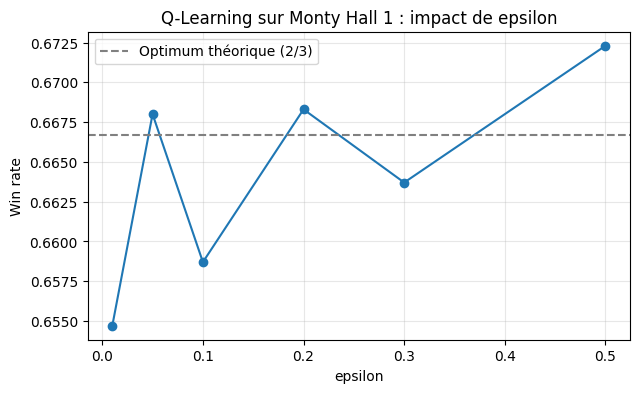

In [22]:
import matplotlib.pyplot as plt
epsilons = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5]
win_rates_eps = []

for eps in epsilons:
    np.random.seed(0)
    pi_test, _ = q_learning(env, gamma=0.999, alpha=0.1, epsilon=eps, num_episodes=20000)
    res = evaluate_policy(env, pi_test, num_episodes=3000)
    win_rates_eps.append(res["win_rate"])

plt.figure(figsize=(7, 4))
plt.plot(epsilons, win_rates_eps, marker="o")
plt.axhline(y=2/3, color="gray", linestyle="--", label="Optimum théorique (2/3)")
plt.xlabel("epsilon")
plt.ylabel("Win rate")
plt.title("Q-Learning sur Monty Hall 1 : impact de epsilon")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("montyhall1_qlearning_epsilon.png", dpi=100, bbox_inches="tight")
plt.show()

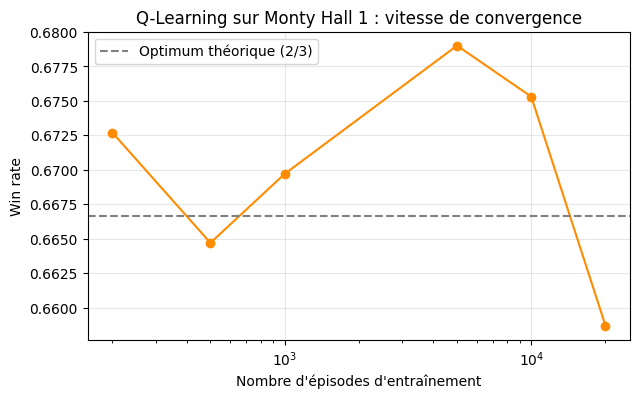

In [23]:
episode_counts = [200, 500, 1000, 5000, 10000, 20000]
win_rates_n = []

for n in episode_counts:
    np.random.seed(0)
    pi_test, _ = q_learning(env, gamma=0.999, alpha=0.1, epsilon=0.1, num_episodes=n)
    res = evaluate_policy(env, pi_test, num_episodes=3000)
    win_rates_n.append(res["win_rate"])

plt.figure(figsize=(7, 4))
plt.plot(episode_counts, win_rates_n, marker="o", color="darkorange")
plt.axhline(y=2/3, color="gray", linestyle="--", label="Optimum théorique (2/3)")
plt.xlabel("Nombre d'épisodes d'entraînement")
plt.ylabel("Win rate")
plt.title("Q-Learning sur Monty Hall 1 : vitesse de convergence")
plt.xscale("log")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("montyhall1_qlearning_episodes.png", dpi=100, bbox_inches="tight")
plt.show()

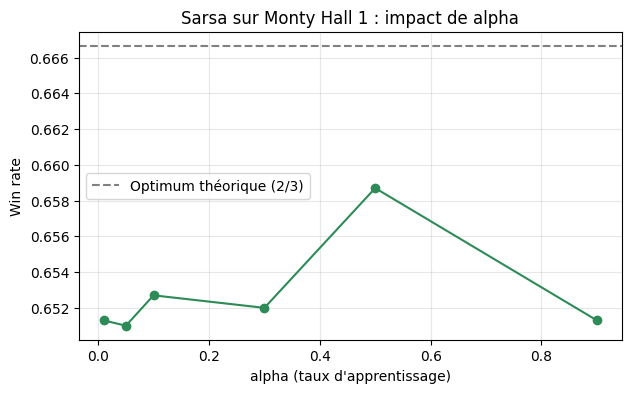

In [24]:
alphas = [0.01, 0.05, 0.1, 0.3, 0.5, 0.9]
win_rates_alpha = []

for a in alphas:
    np.random.seed(0)
    pi_test, _ = sarsa(env, gamma=0.999, alpha=a, epsilon=0.1, num_episodes=20000)
    res = evaluate_policy(env, pi_test, num_episodes=3000)
    win_rates_alpha.append(res["win_rate"])

plt.figure(figsize=(7, 4))
plt.plot(alphas, win_rates_alpha, marker="o", color="seagreen")
plt.axhline(y=2/3, color="gray", linestyle="--", label="Optimum théorique (2/3)")
plt.xlabel("alpha (taux d'apprentissage)")
plt.ylabel("Win rate")
plt.title("Sarsa sur Monty Hall 1 : impact de alpha")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("montyhall1_sarsa_alpha.png", dpi=100, bbox_inches="tight")
plt.show()

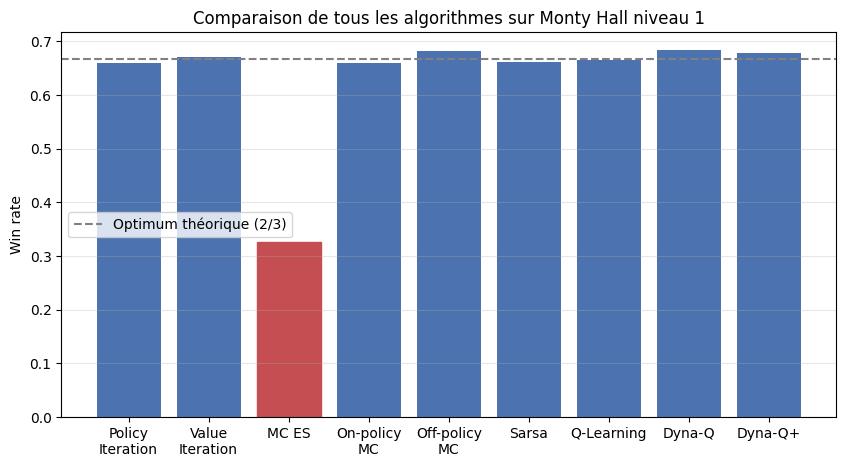

In [25]:
algos_names = ["Policy\nIteration", "Value\nIteration", "MC ES", "On-policy\nMC",
               "Off-policy\nMC", "Sarsa", "Q-Learning", "Dyna-Q", "Dyna-Q+"]
win_rates_all = [results["win_rate"], results_vi["win_rate"], results_mc_es["win_rate"],
                  results_on_mc["win_rate"], results_off_mc["win_rate"], results_sarsa["win_rate"],
                  results_qlearning["win_rate"], results_dyna["win_rate"], results_dyna_plus["win_rate"]]

plt.figure(figsize=(10, 5))
bars = plt.bar(algos_names, win_rates_all, color=["#4C72B0"]*9)
bars[2].set_color("#C44E52")  # MC ES en rouge, seul échec
plt.axhline(y=2/3, color="gray", linestyle="--", label="Optimum théorique (2/3)")
plt.ylabel("Win rate")
plt.title("Comparaison de tous les algorithmes sur Monty Hall niveau 1")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.savefig("montyhall1_comparaison_tous_algos.png", dpi=100, bbox_inches="tight")
plt.show()